# Implémentations possibles de la structure de graphe




On rappelle trois implémentations possibles de la structure de graphe :   
* sous forme de **matrice d'adjacence** ;
* sous forme de **dictionnaire ou liste de listes de successeurs** ;
* sous forme de **classe** (programmation objet).


    
    


## 1. Matrices et listes d'adjacence

### 1.1 Exemple de graphe non orienté, non pondéré avec des sommets numérotés
***Graphe G0***

Considérons le ***graphe G0*** ci-dessous

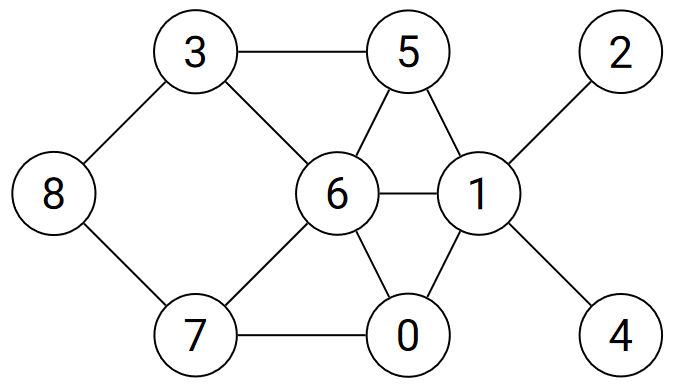

#### 1.1.1 Matrice d'adjacence

Le ***graphe G0*** peut être décrit par une **sa matrice d’adjacence** :

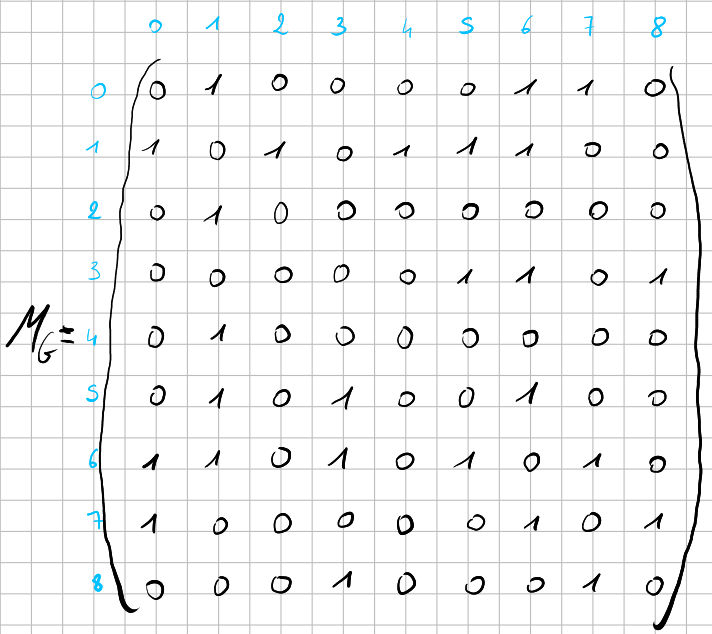


In [ ]:
G0_mat = [ 
  [0, 1, 0, 0, 0, 0, 1, 1, 0], #sommet 0
  [1, 0, 1, 0, 1, 1, 1, 0, 0], #sommet 1
  [0, 1, 0, 0, 0, 0, 0, 0, 0], #sommet 2
  [0, 0, 0, 0, 0, 1, 1, 0, 1], #sommet 3
  [0, 1, 0, 0, 0, 0, 0, 0, 0], #sommet 4
  [0, 1, 0, 1, 0, 0, 1, 0, 0], #sommet 5
  [1, 1, 0, 1, 0, 1, 0, 1, 0], #sommet 6
  [1, 0, 0, 0, 0, 0, 1, 0, 1], #sommet 7
  [0, 0, 0, 1, 0, 0, 0, 1, 0] #sommet 8
]

❓ <font color="green" size="3"><b>Q0. a. Compléter les instructions suivantes pour afficher les différents élèments de la matrice</b></font>

In [ ]:
#affichage des différents éléments de la matrice

# affichage de l'ordre (nombre de sommets) de la matrice : 
# il s'agit du nombre de lignes, donc du nombre de sous-tableaux de G0_mat 
print("Ordre de M : ", len(G0_mat)) 

# affichage de la matrice
print("M =", G0_mat) 

# 2ème ligne
print("Deuxième ligne de M : ", G0_mat[1]) 

# 3ème élément de la 2ème ligne colonne 
print("3ème élément de la 2ème ligne M[2][3] =", G0_mat[1][2]) 

#affichage de la 3ème colonne
col3 = [];      # liste vide
for ligne in G0_mat:
    col3.append(ligne[2])  # ajouter le 3ème élément 
print("colonne 3 de M : ",col3)


❓ <font color="green" size="3"><b>Q0. b. Compléter la fonction permettant d’obtenir le nombre de sommets d'un graphe non orienté défini par sa matrice d'adjacence.</b></font>

In [ ]:
#fonction complétée
def nbSommets(G_mat):
    '''
    Permet d'obtenir le nombre de sommets ou ordre d'un graphe défini par sa matrice d'adjacence
    @param G_mat : matrice d'adjacence d'un graphe G (matrice obligatoirement carrée)
    @return nbSommets : nb de sommets du graphe ou ordre
    '''
    return len(G_mat)

assert nbSommets(G0_mat) == 9

❓ <font color="green" size="3"><b>Q0. c. Compléter la fonction permettant d’obtenir le degré d’un sommet d'un graphe non orienté défini par sa matrice d'adjacence.</b></font>

In [ ]:
#fonction complétée

def degre(G_mat, numSommet):
    '''
    Permet d'obtenir le degré d'un sommet donné dans un graphe défini par sa matrice d'adjacence
    @param G_mat : matrice d'adjacence d'un graphe G (matrice obligatoirement carrée)
    @param numSommet : numéro du sommet dont on veut connaitre le degre
    @return deg_sommet : degre du sommet numéro numSommet dans G
    '''
    deg_sommet = 0
    # parcours de la ligne correspondant au sommet dont on veut le degr2
    for elem in G_mat[numSommet]:
        deg_sommet += elem
    return deg_sommet

assert degre(G0_mat, 0) == 3
assert degre(G0_mat, 1) == 5
assert degre(G0_mat, 2) == 1
assert degre(G0_mat, 3) == 3
assert degre(G0_mat, 4) == 1
assert degre(G0_mat, 5) == 3
assert degre(G0_mat, 6) == 5
assert degre(G0_mat, 7) == 3
assert degre(G0_mat, 8) == 2

❓ <font color="green" size="3"><b>Q0. d. Compléter la fonction permettant d’obtenir le nombre d’arêtes d'un graphe non orienté 
   défini par sa matrice d'adjacence.</b></font>

In [ ]:
# On applique le lemme des poignées de mains 
# -> la somme des degrés des sommets est égale au double du nombre d'arêtes
# On calcule donc la somme des degrés et on divise par 2. 

def nbAretes(G_mat):
    '''
    Permet d'obtenir le nombre d'arêtes d'un graphe défini par sa matrice d'adjacence
    @param G_mat : matrice d'adjacence d'un graphe G (matrice obligatoirement carrée)
    @return nbAretes : nb d'aretes du graphe
    '''
    ordre = len(G_mat)
    somme_degres = 0
    
    for i in range(ordre):
        somme_degres += degre(G_mat, i) 
    return somme_degres // 2

assert(nbAretes(G0_mat) == 13)

In [ ]:
# fonction complétée : version 2
# On se contente de parcourir la partie située sous la diagonale descendante de la matrice

def nbAretes(G_mat):
    '''
    Permet d'obtenir le nombre d'arêtes d'un graphe défini par sa matrice d'adjacence
    @param G_mat : matrice d'adjacence d'un graphe G (matrice obligatoirement carrée)
    @return nbAretes : nb d'aretes du graphe
    '''
    ordre = len(G_mat)
    nbAretes = 0
    for i in range(ordre):
        for j in range(i + 1):
            if G_mat[i][j] != 0:
                nbAretes += 1
    return nbAretes

assert(nbAretes(G0_mat) == 13)

❓ <font color="green" size="3"><b>Q0. e. Compléter la fonction permettant d’obtenir le sommet (ou les sommets) de plus haut degré d'un graphe non orienté défini par sa matrice d'adjacence.</b></font>

In [ ]:
#fonction complétée
def sommetsDegreMax(G_mat):
    '''
    Permet d'obtenir les numeros des sommets de plus haut degré d'un graphe défini par sa matrice d'adjacence
    Par Hector.
    @param G_mat : matrice d'adjacence d'un graphe G (matrice obligatoirement carrée)
    @return numSommetDegreMax : liste des numéros de sommets de degre max
    '''
    score: int = 0
    podium: list = []
    index: int = 0
    while index < nbSommets(G_mat):
        count: int = degre(G_mat, index) 
        
        if count > score:
            score = count
            podium = [index]
            
        elif count == score:
            podium.append(index)
        
        index += 1
    
    return podium

assert sommetsDegreMax(G0_mat) == [1, 6]